# Практическое занятие 9. Сравнительный анализ методов расчета режима энергосистемы

Версия: преподавательская.

Цель занятия - сравнить AC power flow, DC power flow и простую
суррогатную модель машинного обучения. Суррогатная модель
(surrogate model) является приближением расчетной модели и не
заменяет проверку физических ограничений.

## Инициализация среды выполнения

Ячейка ниже обеспечивает запуск блокнота в Google Colab и в
локальном Jupyter Notebook. Если проект уже открыт локально,
повторное клонирование не выполняется.

In [1]:
# COLAB_BOOTSTRAP_APPailab
from pathlib import Path
import os
import sys

REQUIRED_PROCESSED_FILES = ['practice_09_power_flow_comparison_features.csv', 'practice_09_power_flow_comparison_diagnostics.csv', 'practice_09_power_flow_comparison.csv', 'practice_07_09_dataset_catalog.csv', 'practice_07_09_dataset_assignments.csv']
PROJECT_REPOSITORY_URL = "https://github.com/Alexflex/appailab.git"

def find_project_root(start: Path) -> Path | None:
    for candidate in [start, *start.parents]:
        if (candidate / "requirements-colab.txt").exists() and (candidate / "data" / "processed").exists():
            return candidate
    return None

project_root = find_project_root(Path.cwd())

if project_root is None:
    try:
        import google.colab  # type: ignore
        IN_COLAB = True
    except Exception:
        IN_COLAB = False

    if IN_COLAB:
        workdir = Path("/content/appailab")
        if not workdir.exists():
            !git clone -q {PROJECT_REPOSITORY_URL} {workdir}
        project_root = workdir
        os.chdir(project_root)
        !pip install -q -r requirements-colab.txt
    else:
        raise FileNotFoundError(
            "Не найден корень проекта. Откройте блокнот из репозитория appailab "
            "или выполните git clone перед запуском."
        )

sys.path.insert(0, str(project_root / "src"))
missing_files = [
    name for name in REQUIRED_PROCESSED_FILES
    if not (project_root / "data" / "processed" / name).exists()
]
if missing_files:
    raise FileNotFoundError(
        "Не найдены подготовленные CSV: " + ", ".join(missing_files)
        + ". Выполните python scripts/generate_datasets.py."
    )

print(f"Корень проекта: {project_root}")
print("Проверенные CSV:", ", ".join(REQUIRED_PROCESSED_FILES))

Корень проекта: /mnt/f/projects/appai_lab
Проверенные CSV: practice_09_power_flow_comparison_features.csv, practice_09_power_flow_comparison_diagnostics.csv, practice_09_power_flow_comparison.csv, practice_07_09_dataset_catalog.csv, practice_07_09_dataset_assignments.csv


In [2]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import GradientBoostingRegressor, RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

DATA_DIR = project_root / "data" / "processed"
CATALOG_07_09_FILE = DATA_DIR / "practice_07_09_dataset_catalog.csv"
ASSIGNMENTS_07_09_FILE = DATA_DIR / "practice_07_09_dataset_assignments.csv"
RANDOM_STATE = 20260507

## Теоретический блок

AC power flow учитывает активные и реактивные мощности, модули и
углы напряжений. DC power flow - линейное приближение, в котором
обычно предполагаются малые углы, близкие к номинальным напряжения
и малые потери. Поэтому DC-расчет полезен для быстрого анализа
активных перетоков, но не является универсальной заменой AC-расчету.

Ошибка сравнения:

$$
e_l = P^{AC}_l - P^{DC}_l.
$$

Здесь `l` - номер линии сети.

In [3]:
features_df = pd.read_csv(DATA_DIR / "practice_09_power_flow_comparison_features.csv")
diagnostics_df = pd.read_csv(DATA_DIR / "practice_09_power_flow_comparison_diagnostics.csv")
full_df = pd.read_csv(DATA_DIR / "practice_09_power_flow_comparison.csv")

print("features:", features_df.shape)
print("diagnostics:", diagnostics_df.shape)
print("full:", full_df.shape)
display(features_df.head())
display(diagnostics_df[[
    "scenario_id", "mean_abs_line_error_mw",
    "max_abs_line_error_mw", "mean_relative_line_error_percent"
]].head())

features: (120, 15)
diagnostics: (120, 30)
full: (120, 44)


,scenario_id,scenario_label,load_scale,generator_p_mw,generator_vm_pu,load_bus_2_mw,load_bus_2_mvar,load_bus_3_mw,load_bus_3_mvar,load_bus_4_mw,load_bus_4_mvar,load_bus_5_mw,load_bus_5_mvar,min_vm_pu,max_line_loading_percent
0,1,base,1.0000,35.0000,1.01000,29.2651,10.4014,24.3143,8.0800,26.6198,8.8305,16.7234,5.2234,0.99889,72.065
1,2,random_operating_point,0.8809,29.4418,1.02678,28.8040,10.9120,24.0267,8.8749,20.3105,7.8871,14.7974,4.9755,1.01413,70.406
2,3,random_operating_point,1.2000,29.3818,1.01905,40.3696,14.8323,30.3518,10.2967,35.5466,11.7926,20.6785,7.4098,1.00130,114.639
3,4,random_operating_point,0.9092,44.0281,1.02416,30.6055,10.1539,20.4259,6.9603,25.1330,9.0073,15.2678,5.6387,1.01102,56.245
4,5,high_load,1.2504,33.9256,1.00148,44.7200,16.8040,27.6618,8.7903,34.7358,11.9680,23.6438,7.3509,0.98498,114.117


,scenario_id,mean_abs_line_error_mw,max_abs_line_error_mw,mean_relative_line_error_percent
0,1,0.22288,0.88375,0.847
1,2,0.22750,0.82892,17.632
2,3,0.54225,2.09033,1.491
3,4,0.19314,0.65561,1.002
4,5,0.52074,2.10752,1.534


## Сравнение AC- и DC-перетоков

На графике каждая точка соответствует одной линии одного сценария.
Чем ближе точка к диагонали, тем меньше расхождение между
нелинейным AC-расчетом и линейным DC-приближением.

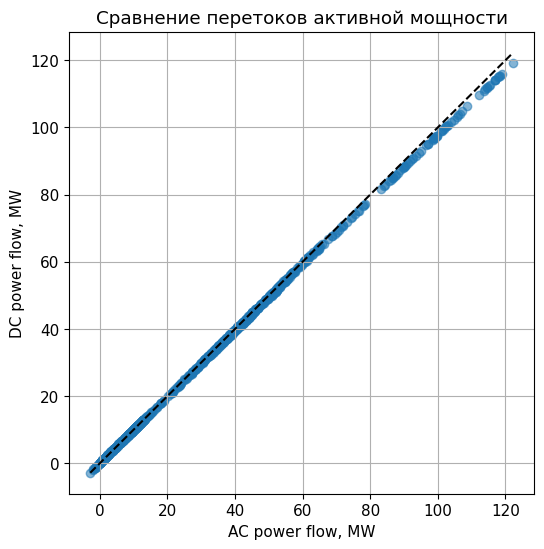

In [4]:
ac_cols = [f"ac_line_{i}_p_mw" for i in range(1, 8)]
dc_cols = [f"dc_line_{i}_p_mw" for i in range(1, 8)]
ac_values = diagnostics_df[ac_cols].to_numpy().ravel()
dc_values = diagnostics_df[dc_cols].to_numpy().ravel()

plt.figure(figsize=(6, 6))
plt.scatter(ac_values, dc_values, alpha=0.55)
lo = min(ac_values.min(), dc_values.min())
hi = max(ac_values.max(), dc_values.max())
plt.plot([lo, hi], [lo, hi], color="black", linestyle="--")
plt.xlabel("AC power flow, MW")
plt.ylabel("DC power flow, MW")
plt.title("Сравнение перетоков активной мощности")
plt.show()

,mean_abs_line_error_mw,max_abs_line_error_mw,mean_relative_line_error_percent
count,120.0000,120.0000,120.0000
mean,0.4065,1.5758,2.0472
std,0.1853,0.7404,3.1197
min,0.0985,0.3247,0.4610
25%,0.2468,0.9193,1.1238
50%,0.4137,1.6052,1.3645
75%,0.5488,2.1291,1.7280
max,0.7875,3.0329,28.1810


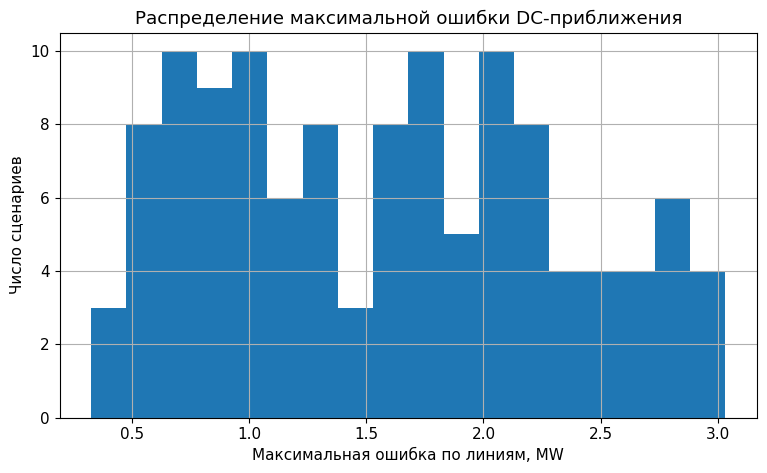

In [5]:
error_summary = diagnostics_df[[
    "mean_abs_line_error_mw",
    "max_abs_line_error_mw",
    "mean_relative_line_error_percent",
]].describe().round(4)
display(error_summary)

diagnostics_df["max_abs_line_error_mw"].hist(bins=18)
plt.xlabel("Максимальная ошибка по линиям, MW")
plt.ylabel("Число сценариев")
plt.title("Распределение максимальной ошибки DC-приближения")
plt.show()

## Безопасные признаки суррогатной модели

Суррогатная модель должна получать только входы сценария: нагрузки,
реактивные нагрузки, уставку генератора и масштаб нагрузки. В нее
нельзя включать AC-перетоки и уже рассчитанные напряжения из той же
строки, иначе получится утечка данных.

In [6]:
surrogate_features = ['load_scale', 'generator_p_mw', 'generator_vm_pu', 'load_bus_2_mw', 'load_bus_2_mvar', 'load_bus_3_mw', 'load_bus_3_mvar', 'load_bus_4_mw', 'load_bus_4_mvar', 'load_bus_5_mw', 'load_bus_5_mvar']

forbidden_surrogate_features = {'min_vm_pu', 'max_line_loading_percent', 'total_line_loss_mw', 'critical_line', 'weak_bus'}
forbidden_surrogate_features |= {f'ac_line_{i}_p_mw' for i in range(1, 8)}
forbidden_surrogate_features |= {f'dc_line_{i}_p_mw' for i in range(1, 8)}
leaked = forbidden_surrogate_features & set(surrogate_features)
if leaked:
    raise ValueError(f'Обнаружена утечка данных: {sorted(leaked)}')

In [7]:
surrogate_target = 'max_line_loading_percent'

if surrogate_target not in {'max_line_loading_percent', 'min_vm_pu'}:
    raise ValueError("surrogate_target должен быть 'max_line_loading_percent' или 'min_vm_pu'.")

In [8]:
surrogate_max_depth = 6

## Обучение суррогатной модели

В этом примере прогнозируется расчетный AC-показатель по входным
параметрам сценария. Метрики MAE, RMSE и R2 показывают точность
приближения, но не отменяют необходимости контрольного AC-расчета.

In [9]:
X = features_df[surrogate_features]
y = features_df[surrogate_target]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE
)

surrogate_model = RandomForestRegressor(
    n_estimators=180,
    max_depth=surrogate_max_depth,
    min_samples_leaf=4,
    random_state=RANDOM_STATE,
)
surrogate_model.fit(X_train, y_train)
y_pred = surrogate_model.predict(X_test)

rmse = mean_squared_error(y_test, y_pred) ** 0.5
metrics = {
    "MAE": mean_absolute_error(y_test, y_pred),
    "RMSE": rmse,
    "R2": r2_score(y_test, y_pred),
}
display(pd.DataFrame([metrics]).round(4))

,MAE,RMSE,R2
0,6.4902,7.8177,0.9251


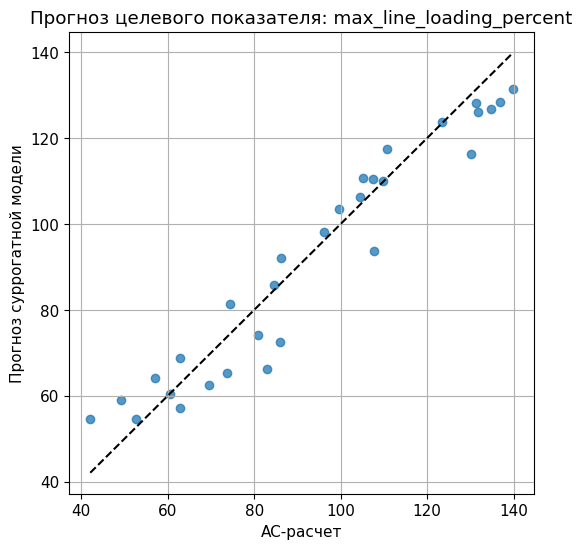

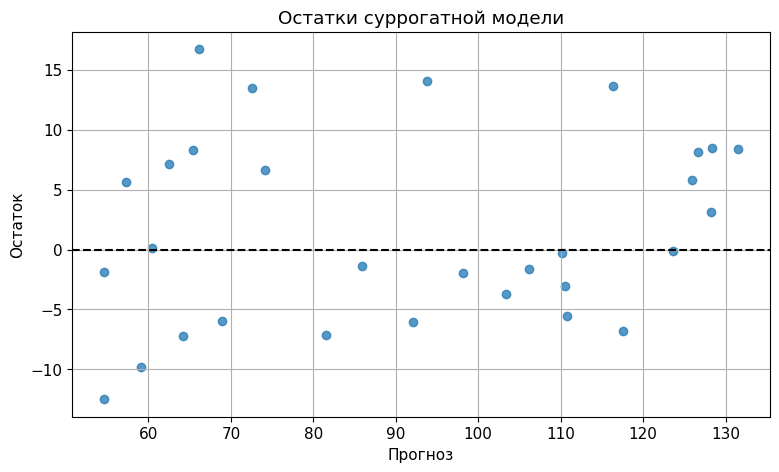

In [10]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.75)
lo = min(y_test.min(), y_pred.min())
hi = max(y_test.max(), y_pred.max())
plt.plot([lo, hi], [lo, hi], color="black", linestyle="--")
plt.xlabel("AC-расчет")
plt.ylabel("Прогноз суррогатной модели")
plt.title(f"Прогноз целевого показателя: {surrogate_target}")
plt.show()

residuals = y_test - y_pred
plt.scatter(y_pred, residuals, alpha=0.75)
plt.axhline(0.0, color="black", linestyle="--")
plt.xlabel("Прогноз")
plt.ylabel("Остаток")
plt.title("Остатки суррогатной модели")
plt.show()

## АНТИПРИМЕР: использование AC-результатов как входов

Если добавить `ac_line_1_p_mw` и другие результаты AC-расчета в
признаки, модель получает информацию, вычисленную той же физической
моделью. Это искусственно завышает качество и не является честной
суррогатной моделью.

In [11]:
leakage_df = features_df.merge(diagnostics_df, on="scenario_id", validate="one_to_one")
leakage_features = surrogate_features + ["ac_line_1_p_mw", "ac_line_2_p_mw", "total_line_loss_mw"]
X_leak = leakage_df[leakage_features]
y_leak = leakage_df[surrogate_target]
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_leak, y_leak, test_size=0.25, random_state=RANDOM_STATE
)
leakage_model = RandomForestRegressor(n_estimators=180, random_state=RANDOM_STATE)
leakage_model.fit(X_train_l, y_train_l)
leakage_pred = leakage_model.predict(X_test_l)
print("Запрещенный R2 с AC-утечкой:", round(r2_score(y_test_l, leakage_pred), 4))

Запрещенный R2 с AC-утечкой: 0.9945


In [12]:
comparison_interpretation = 'DC-приближение дает малую среднюю ошибку для учебной transmission-like сети, но максимальная ошибка по отдельным линиям требует отдельного контроля.'
print(comparison_interpretation)

DC-приближение дает малую среднюю ошибку для учебной transmission-like сети, но максимальная ошибка по отдельным линиям требует отдельного контроля.


## Источники и проверка актуальности

Базовые занятия 7-9 используют локальные воспроизводимые CSV. Открытые
источники ниже применяются как методические задания: студент должен
определить объект, признаки, целевую переменную, риски утечки данных
и допустимые визуализации.

In [13]:
catalog_07_09 = pd.read_csv(CATALOG_07_09_FILE)
assignments_07_09 = pd.read_csv(ASSIGNMENTS_07_09_FILE)
display(catalog_07_09[[
    "dataset_id", "name", "lessons", "implementation_status",
    "risk_level", "checked_at"
]])

,dataset_id,name,lessons,implementation_status,risk_level,checked_at
0,mendeley_pd_cables_toa,Partial Discharge Signals in Insulated Power C...,7,methodology_only,средний,2026-05-16
1,zenodo_pd_calibrator,Dataset for New Synthetic Partial Discharge Ca...,7,methodology_only,низкий,2026-05-16
2,pandapower_case9,pandapower IEEE 9-bus example network,"8,9",methodology_only,низкий,2026-05-16
3,ieee_pes_test_feeders,IEEE PES Distribution Test Feeders,"8,9",methodology_only,средний,2026-05-16
4,matpower_cases,MATPOWER case archive,"8,9",methodology_only,средний,2026-05-16


## Реестр найденных наборов данных и развернутые задания

Все источники имеют статус `methodology_only`, то есть на данном
этапе они не являются обязательными для выполнения в аудитории.

In [14]:
display(assignments_07_09[[
    "assignment_id", "lesson", "assignment_title",
    "recommended_visualizations", "control_questions"
]])

,assignment_id,lesson,assignment_title,recommended_visualizations,control_questions
0,mendeley_pd_cables_toa_lesson_7,7,Извлечение признаков из сигналов: Partial Disc...,временной сигнал; спектр; таблица признаков; м...,Почему шаг дискретизации входит в расчет энерг...
1,zenodo_pd_calibrator_lesson_7,7,Извлечение признаков из сигналов: Dataset for ...,временной сигнал; спектр; таблица признаков; м...,Почему шаг дискретизации входит в расчет энерг...
2,pandapower_case9_lesson_8,8,Расчет режима по открытой тестовой сети: panda...,таблица напряжений; диаграмма загрузки линий; ...,Что является входом расчета? Почему расчет реж...
3,pandapower_case9_lesson_9,9,Сравнение AC/DC и суррогатной модели: pandapow...,AC против DC; распределение ошибок; график про...,Когда DC-приближение допустимо? Почему AC-резу...
4,ieee_pes_test_feeders_lesson_8,8,Расчет режима по открытой тестовой сети: IEEE ...,таблица напряжений; диаграмма загрузки линий; ...,Что является входом расчета? Почему расчет реж...
5,ieee_pes_test_feeders_lesson_9,9,Сравнение AC/DC и суррогатной модели: IEEE PES...,AC против DC; распределение ошибок; график про...,Когда DC-приближение допустимо? Почему AC-резу...
6,matpower_cases_lesson_8,8,Расчет режима по открытой тестовой сети: MATPO...,таблица напряжений; диаграмма загрузки линий; ...,Что является входом расчета? Почему расчет реж...
7,matpower_cases_lesson_9,9,Сравнение AC/DC и суррогатной модели: MATPOWER...,AC против DC; распределение ошибок; график про...,Когда DC-приближение допустимо? Почему AC-резу...


## Контрольный чек-лист отчета

1. Объяснены отличия AC power flow и DC power flow.
2. Рассчитаны MAE/RMSE или абсолютные ошибки по линиям.
3. Построено сравнение AC и DC перетоков.
4. Суррогатная модель обучена только на входах сценария.
5. Антипример утечки данных явно отделен от основного результата.